# mmCIF base-pair annotations → PyTorch Geometric graphs

This notebook reads an **NDB / NAPAIR base-pair-annotation mmCIF** file and turns it into
[PyTorch Geometric](https://pytorch-geometric.readthedocs.io/) graphs where

- **nodes = nucleotide residues** (the "molecules"), and
- **edges = annotated base pairs**.

## The input format

These files are *not* coordinate mmCIFs — they hold only base-pair annotations, in a handful of
custom `loop_` categories:

| category | what it is | role here |
|---|---|---|
| `_ndb_base_pair_provenance` | software metadata (NAPAIR v1.0) | ignored |
| `_ndb_base_pair_list` | each annotated base pair, **per PDB model** | **edges** |
| `_ndb_base_pair_annotation` | Leontis–Westhof family (cWW, tWS…), orientation, edges | edge labels |
| `_ndb_base_pair_validation` | `napair_rmsd`, `napasco_metric`, preferred / of_concern | edge features |
| `_ndb_base_unpaired_list` | residues with no pair, **per model** | isolated nodes |

A base pair in `_ndb_base_pair_list` points at two residues, each identified by
`label_asym_id` (chain), `label_seq_id` (position) and `label_comp_id` (G/C/A/U or a modified base).
The `_ndb_base_pair_annotation` and `_ndb_base_pair_validation` rows join back to it via
`base_pair_id`.

Because the file carries several **PDB models** (alternative conformations of the same molecule),
we build **one graph per model**.

In [1]:
from pathlib import Path

import pandas as pd
import torch

from mmcif_to_pyg import parse_ndb_mmcif, build_graphs, mmcif_to_pyg, sequence

MMCIF = Path("../../../data/00008bwt.mmcif").resolve()
print(MMCIF, MMCIF.exists())

/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/cw_liao/na-hackathon-2026/data/00008bwt.mmcif True


## 1. Read the raw annotation tables

`parse_ndb_mmcif` uses [gemmi](https://gemmi.readthedocs.io/) to pull each category out as a
column-oriented dict. Below we view them as DataFrames just to see the shape of the data.

In [2]:
tables = parse_ndb_mmcif(MMCIF)
print("entry:", tables.entry_id)
print("base pairs (all models):", tables.n_pairs())

bp_df = pd.DataFrame(tables.base_pair_list)
bp_df.head(6)

entry: 8BWT
base pairs (all models): 113


,id,PDB_model_num,label_asym_id_1,label_entity_id_1,label_seq_id_1,label_comp_id_1,PDB_ins_code_1,label_alt_id_1,struct_oper_id_1,label_asym_id_2,label_entity_id_2,label_seq_id_2,label_comp_id_2,PDB_ins_code_2,label_alt_id_2,struct_oper_id_2,auth_asym_id_1,auth_seq_id_1,auth_asym_id_2,auth_seq_id_2
0,1,1,A,1,1,G,None,False,1,A,1,26,C,None,False,1,A,1,A,26
1,2,1,A,1,2,G,None,False,1,A,1,25,C,None,False,1,A,2,A,25
2,3,1,A,1,4,G,None,False,1,A,1,23,C,None,False,1,A,4,A,23
3,4,1,A,1,7,U,None,False,1,A,1,20,U,None,False,1,A,7,A,20
4,5,1,A,1,8,U,None,False,1,A,1,19,U,None,False,1,A,8,A,19
5,6,1,A,1,10,G,None,False,1,A,1,17,C,None,False,1,A,10,A,17


In [3]:
# Annotation + validation, joined on the base-pair id, for model 1.
ann_df = pd.DataFrame(tables.annotation)
val_df = pd.DataFrame(tables.validation)
joined = (
    bp_df.merge(ann_df, left_on="id", right_on="base_pair_id", suffixes=("", "_ann"))
         .merge(val_df, left_on="id", right_on="base_pair_id", suffixes=("", "_val"))
)
cols = ["PDB_model_num", "label_comp_id_1", "label_seq_id_1", "label_comp_id_2",
        "label_seq_id_2", "l-w_family_name", "orientation", "napair_rmsd",
        "napasco_metric", "napasco_annotation"]
joined[joined.PDB_model_num == "1"][cols].reset_index(drop=True)

,PDB_model_num,label_comp_id_1,label_seq_id_1,label_comp_id_2,label_seq_id_2,l-w_family_name,orientation,napair_rmsd,napasco_metric,napasco_annotation
0,1,G,1,C,26,cWW,cis,0.268,27.72,preferred
1,1,G,2,C,25,cWW,cis,0.398,16.93,preferred
2,1,G,4,C,23,cWW,cis,0.242,32.73,preferred
3,1,U,7,U,20,cWW,cis,0.462,23.35,preferred
4,1,U,8,U,19,cWW,cis,0.354,37.29,preferred
5,1,G,10,C,17,cWW,cis,0.473,11.29,preferred
6,1,G,16,C,11,cWW,cis,0.755,3.29,of_concern
7,1,G,18,C,9,cWW,cis,0.608,5.56,preferred
8,1,U,21,U,6,cWW,cis,0.843,6.40,preferred
9,1,A,22,U,5,cWW,cis,0.473,4.52,of_concern


## 2. Build the graphs

`build_graphs` (or the one-shot `mmcif_to_pyg`) returns a list of `torch_geometric.data.Data`,
one per model. Node and edge vocabularies (residue types, LW families) are shared across all
models so the integer encodings line up.

In [4]:
graphs = mmcif_to_pyg(MMCIF)
print(f"{len(graphs)} graphs (one per model)\n")
for g in graphs:
    n_pairs = g.edge_index.size(1) // 2  # undirected: 2 directed edges per pair
    n_unpaired = int((~g.node_is_paired).sum())
    print(f"model {g.model_num:>2}: {g.num_nodes} nodes "
          f"({n_unpaired} unpaired), {n_pairs} base pairs")

10 graphs (one per model)

model  1: 26 nodes (4 unpaired), 11 base pairs
model  2: 26 nodes (4 unpaired), 11 base pairs
model  3: 26 nodes (2 unpaired), 12 base pairs
model  4: 26 nodes (4 unpaired), 11 base pairs
model  5: 26 nodes (4 unpaired), 11 base pairs
model  6: 26 nodes (4 unpaired), 11 base pairs
model  7: 26 nodes (4 unpaired), 11 base pairs
model  8: 26 nodes (2 unpaired), 12 base pairs
model  9: 26 nodes (2 unpaired), 12 base pairs
model 10: 26 nodes (4 unpaired), 11 base pairs


## 3. Inspect one graph

Each `Data` object holds the standard PyG tensors plus annotation metadata:

- `x` — one-hot of the residue type (`nt_vocab` gives the column order)
- `edge_index` — `[2, 2 × n_pairs]`, every pair stored in both directions
- `edge_attr` — columns named in `edge_attr_columns`
- `edge_lw_family` — integer index into `lw_vocab` (cWW, tWS, …)
- `node_*` / `edge_*` lists — human-readable labels

In [5]:
g = graphs[0]
print(g)
print("\nnt_vocab        :", g.nt_vocab)
print("lw_vocab        :", g.lw_vocab)
print("edge_attr cols  :", g.edge_attr_columns)

print("\nsequence (5'->3'):", sequence(g))
print("unpaired (seq id):", g.node_seq_id[~g.node_is_paired].tolist())

Data(x=[26, 4], edge_index=[2, 22], edge_attr=[22, 6], num_nodes=26, edge_lw_family=[22], entry_id='8BWT', model_num=1, node_comp_id=[26], node_asym_id=[26], node_seq_id=[26], node_is_paired=[26], edge_orientation=[22], edge_base_edges=[22], edge_class=[22], edge_annotation=[22], nt_vocab=[4], lw_vocab=[2], edge_attr_columns=[6])

nt_vocab        : ['A', 'C', 'G', 'U']
lw_vocab        : ['cWW', 'tWS']
edge_attr cols  : ['orient_cis', 'orient_trans', 'napair_rmsd', 'napasco_metric', 'ann_preferred', 'ann_of_concern']

sequence (5'->3'): GGCGUUUUCGCUUCGGCGUUUACGCC
unpaired (seq id): [12, 13, 14, 15]


In [6]:
# Per-edge table for this model (undirected, so show every other directed edge).
rows = []
for e in range(0, g.edge_index.size(1), 2):
    i, j = g.edge_index[:, e].tolist()
    a = g.edge_attr[e]
    rows.append({
        "base_1": f"{g.node_comp_id[i]}{g.node_seq_id[i].item()}",
        "base_2": f"{g.node_comp_id[j]}{g.node_seq_id[j].item()}",
        "lw_family": g.lw_vocab[g.edge_lw_family[e]],
        "orientation": g.edge_orientation[e],
        "napair_rmsd": round(a[2].item(), 3),
        "napasco": round(a[3].item(), 2),
        "annotation": g.edge_annotation[e],
    })
pd.DataFrame(rows)

,base_1,base_2,lw_family,orientation,napair_rmsd,napasco,annotation
0,G1,C26,cWW,cis,0.268,27.72,preferred
1,G2,C25,cWW,cis,0.398,16.93,preferred
2,G4,C23,cWW,cis,0.242,32.73,preferred
3,U7,U20,cWW,cis,0.462,23.35,preferred
4,U8,U19,cWW,cis,0.354,37.29,preferred
5,G10,C17,cWW,cis,0.473,11.29,preferred
6,G16,C11,cWW,cis,0.755,3.29,of_concern
7,G18,C9,cWW,cis,0.608,5.56,preferred
8,U21,U6,cWW,cis,0.843,6.40,preferred
9,A22,U5,cWW,cis,0.473,4.52,of_concern


## 4. Visualize the secondary structure (arc diagram)

A force-directed layout of *only* the base-pair edges has no backbone information, so it can't
recover the hairpin shape — it just scatters the pairs into a ladder. The standard, unambiguous
way to draw RNA secondary structure is an **arc diagram**: the sequence lies on a line (5'→3'),
the backbone is the line itself, and each base pair is an arc above it.

Nested arcs ⇒ a stem; the gap under the innermost arc ⇒ the loop. For 8BWT this is a clean
**hairpin** (verified to be fully nested / pseudoknot-free across all 10 models):

```
model 1: GGCGUUUUCGCUUCGGCGUUUACGCC
         (((((((((((....)))))))))))
```

- **solid** arc = canonical cWW pair, **dashed** = non-canonical (e.g. tWS)
- **red** arc = pair flagged `of_concern` by validation
- gray node = unpaired residue (the loop)

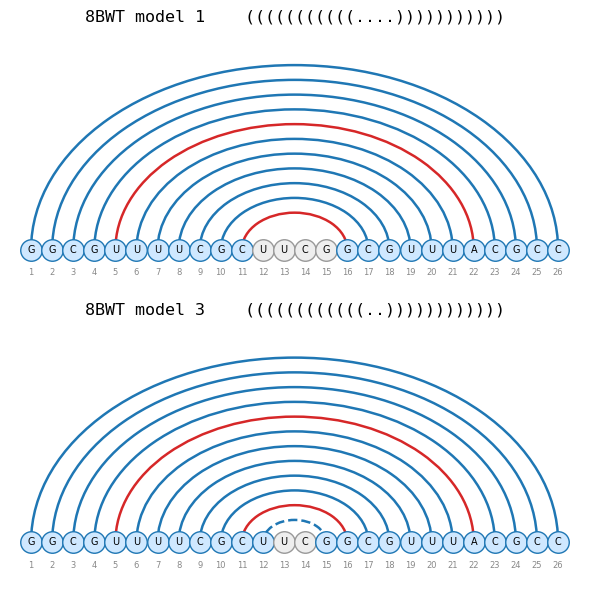

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc


def dot_bracket(g):
    """Dot-bracket string for a nested (pseudoknot-free) graph."""
    order = sorted(range(g.num_nodes), key=lambda i: g.node_seq_id[i].item())
    xpos = {node: k for k, node in enumerate(order)}
    db = ["."] * len(order)
    for e in range(0, g.edge_index.size(1), 2):
        i, j = g.edge_index[:, e].tolist()
        a, b = sorted((xpos[i], xpos[j]))
        db[a], db[b] = "(", ")"
    return "".join(db)


def arc_diagram(g, ax):
    order = sorted(range(g.num_nodes), key=lambda i: g.node_seq_id[i].item())
    xpos = {node: k for k, node in enumerate(order)}
    n = len(order)
    ax.plot([0, n - 1], [0, 0], color="#bbbbbb", lw=1, zorder=0)  # backbone
    for node in order:
        x = xpos[node]
        paired = bool(g.node_is_paired[node])
        ax.scatter([x], [0], s=240, zorder=3,
                   color="#cfe8ff" if paired else "#eeeeee",
                   edgecolors="#1f77b4" if paired else "#999999")
        ax.text(x, 0, g.node_comp_id[node], ha="center", va="center", fontsize=7, zorder=4)
        ax.text(x, -1.1, str(g.node_seq_id[node].item()), ha="center", va="center",
                fontsize=6, color="#888888")
    for e in range(0, g.edge_index.size(1), 2):
        i, j = g.edge_index[:, e].tolist()
        xi, xj = sorted((xpos[i], xpos[j]))
        concern = g.edge_annotation[e] == "of_concern"
        canonical = g.lw_vocab[g.edge_lw_family[e]] == "cWW"
        w = xj - xi
        ax.add_patch(Arc(((xi + xj) / 2, 0), w, w * 0.7, theta1=0, theta2=180,
                         color="#d62728" if concern else "#1f77b4",
                         lw=1.8, linestyle="-" if canonical else "--", zorder=2))
    ax.set_xlim(-1, n)
    ax.set_ylim(-1.8, n * 0.4)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for ax, idx in zip(axes, (0, 2)):  # model 1 and model 3
    g = graphs[idx]
    arc_diagram(g, ax)
    ax.set_title(f"{g.entry_id} model {g.model_num}    {dot_bracket(g)}", fontfamily="monospace")
plt.tight_layout()
plt.show()

## 5. Use the graphs with PyG

The per-model graphs are ordinary `Data` objects, so they batch with a standard
`DataLoader`. Here we mini-batch all 10 model graphs into one disconnected graph.

In [8]:
from torch_geometric.loader import DataLoader

loader = DataLoader(graphs, batch_size=4, shuffle=False)
batch = next(iter(loader))
print(batch)
print("graphs in batch :", int(batch.num_graphs))
print("total nodes     :", batch.num_nodes)
print("node->graph map :", batch.batch.tolist())

DataBatch(x=[104, 4], edge_index=[2, 90], edge_attr=[90, 6], num_nodes=104, edge_lw_family=[90], entry_id=[4], model_num=[4], node_comp_id=[4], node_asym_id=[4], node_seq_id=[104], node_is_paired=[104], edge_orientation=[4], edge_base_edges=[4], edge_class=[4], edge_annotation=[4], nt_vocab=[4], lw_vocab=[4], edge_attr_columns=[4], batch=[104], ptr=[5])
graphs in batch : 4
total nodes     : 104
node->graph map : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


## 6. Save / load

Persist the list of graphs with `torch.save`; reload anywhere the same classes are importable.
(The CLI does the same thing: `pixi run python mmcif_to_pyg.py <file> -o graphs.pt`.)

In [9]:
out = Path("graphs_8bwt.pt")
torch.save(graphs, out)
reloaded = torch.load(out, weights_only=False)
print("saved", len(reloaded), "graphs to", out.resolve())

saved 10 graphs to /Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/graphs_8bwt.pt
